# Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, Optional, Any
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message=r".*Creating legend with loc=\"best\".*",
    category=UserWarning,
)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

# Data Creation

In [2]:
@dataclass
class ModelParameters:
    """
    Container for cross-lagged model parameters for DAILY measurements.

    Exercise is measured in MINUTES per day (typical 0-60).
    Mood is measured on a 5-point ordinal scale (0-4).
    Sleep is measured in HOURS per night (4-12 typical range).
    """
    # Time period specification
    time_period: str = "daily"

    # Mood equation parameters (daily mood rating 0-4)
    beta_mood_intercept: float = 0.0
    beta_mood_autoreg: float = 0.5       # Yesterday's mood affects today's
    beta_exercise_to_mood: float = 0.015 # Per 10 minutes of exercise
    beta_sleep_to_mood: float = 0.15     # Per hour of sleep
    sigma_mood_random: float = 0.8
    sigma_mood_residual: float = 1.0

    # Exercise probability equation parameters (logistic)
    beta_prob_intercept: float = -0.5     # Baseline log-odds of exercising
    beta_prob_autoreg: float = 0.8        # Exercising yesterday -> today
    beta_prob_mood: float = 0.2           # Better mood -> more likely to exercise
    beta_prob_sleep: float = 0.1          # Per hour of sleep
    sigma_prob_random: float = 0.5        # Between-person variability

    # Exercise duration equation parameters (when exercising)
    beta_duration_intercept: float = 3.4   # log(30) = 3.4, baseline ~30 min
    beta_duration_autoreg: float = 0.3     # Duration persistence
    beta_duration_mood: float = 0.05       # Better mood -> longer duration
    beta_duration_sleep: float = 0.02      # Per hour of sleep
    sigma_duration_random: float = 0.3     # Between-person variability
    sigma_duration_residual: float = 0.25  # Within-person variability

    # Sleep AR(1) parameters (hours per night)
    phi_sleep: float = 0.7      # Sleep patterns are somewhat consistent
    sigma_sleep: float = 1.0    # +/-1 hour variation
    mean_sleep: float = 7.5     # Average 7.5 hours per night

    # Ordinal thresholds for mood scale
    mood_thresholds: np.ndarray = None

    def __post_init__(self):
        if self.mood_thresholds is None:
            self.mood_thresholds = np.array([-1.5, -0.5, 0.5, 1.5])

In [3]:
@dataclass
class PanelData:
    """
    Container for DAILY panel data and metadata.

    Attributes:
    - mood: Daily mood ratings (0-4 ordinal scale)
    - exercise: Minutes of exercise per day
    - sleep: Hours of sleep per night
    """
    mood: np.ndarray
    exercise: np.ndarray
    sleep: np.ndarray
    subject_random_effects: Dict[str, np.ndarray]
    n_subjects: int
    n_days: int

    def to_dataframe(self) -> pd.DataFrame:
        """Convert to long-format DataFrame."""
        data_list = []
        for i in range(self.n_subjects):
            for t in range(self.n_days):
                data_list.append({
                    'subject_id': i,
                    'day': t,
                    'mood': self.mood[i, t],
                    'exercise_minutes': self.exercise[i, t],
                    'sleep_hours': self.sleep[i, t]
                })
        return pd.DataFrame(data_list)

In [4]:
class DataGenerator:
    """Generate synthetic cross-lagged panel data for daily measurements."""

    def __init__(self, params: ModelParameters, seed: int = 42):
        self.params = params
        self.rng = np.random.default_rng(seed)

    def generate(self, n_subjects: int, n_days: int) -> PanelData:
        """
        Generate panel data with cross-lagged dynamics.

        Exercise is generated with a two-part model:
        1. Whether to exercise (Bernoulli process)
        2. Duration if exercising (Log-normal process)
        Both parts have cross-lagged predictors.
        """
        # Random intercepts for all three processes
        u_mood = self.rng.normal(0, self.params.sigma_mood_random, n_subjects)
        u_prob = self.rng.normal(0, self.params.sigma_prob_random, n_subjects)
        u_duration = self.rng.normal(0, self.params.sigma_duration_random, n_subjects)

        # Initialize arrays
        sleep = np.zeros((n_subjects, n_days))
        mood_latent = np.zeros((n_subjects, n_days))
        mood = np.zeros((n_subjects, n_days), dtype=int)
        exercise = np.zeros((n_subjects, n_days))

        # Generate initial values
        # Sleep: around 7.5 hours with some variation
        sleep[:, 0] = np.clip(
            self.rng.normal(self.params.mean_sleep, self.params.sigma_sleep, n_subjects),
            4.0, 12.0
        )

        # Initial mood
        mood_latent[:, 0] = self.rng.normal(
            u_mood + self.params.beta_mood_intercept,
            self.params.sigma_mood_residual
        )
        mood[:, 0] = np.searchsorted(self.params.mood_thresholds, mood_latent[:, 0])

        # Initial exercise (two-part model)
        # Part 1: Probability of exercising
        logit_prob = (u_prob + self.params.beta_prob_intercept +
                     self.params.beta_prob_mood * mood[:, 0] +
                     self.params.beta_prob_sleep * sleep[:, 0])
        prob_exercise = 1 / (1 + np.exp(-logit_prob))
        exercises = self.rng.random(n_subjects) < prob_exercise

        # Part 2: Duration if exercising
        log_duration = (u_duration + self.params.beta_duration_intercept +
                       self.params.beta_duration_mood * mood[:, 0] +
                       self.params.beta_duration_sleep * sleep[:, 0])
        duration_if_exercise = np.exp(
            log_duration +
            self.rng.normal(0, self.params.sigma_duration_residual, n_subjects)
        )

        exercise[:, 0] = np.where(exercises, np.clip(duration_if_exercise, 5, 90), 0)

        # Generate subsequent days
        for t in range(1, n_days):
            # Update sleep (AR1 process)
            sleep[:, t] = np.clip(
                self.params.phi_sleep * sleep[:, t-1] +
                (1 - self.params.phi_sleep) * self.params.mean_sleep +
                self.rng.normal(0, self.params.sigma_sleep, n_subjects),
                4.0, 12.0
            )

            # Update mood (uses actual exercise minutes from yesterday)
            exercise_effect = (exercise[:, t-1] / 10) * self.params.beta_exercise_to_mood

            mu_mood = (
                u_mood +
                self.params.beta_mood_intercept +
                self.params.beta_mood_autoreg * mood[:, t-1] +
                exercise_effect +
                self.params.beta_sleep_to_mood * sleep[:, t-1]
            )
            mood_latent[:, t] = self.rng.normal(mu_mood, self.params.sigma_mood_residual)
            mood[:, t] = np.searchsorted(self.params.mood_thresholds, mood_latent[:, t])

            # Update exercise (two-part model with cross-lagged predictors)
            # Part 1: Probability of exercising
            exercised_yesterday = (exercise[:, t-1] > 0).astype(float)
            logit_prob = (
                u_prob + self.params.beta_prob_intercept +
                self.params.beta_prob_autoreg * exercised_yesterday +
                self.params.beta_prob_mood * mood[:, t-1] +
                self.params.beta_prob_sleep * sleep[:, t-1]
            )
            prob_exercise = 1 / (1 + np.exp(-logit_prob))
            exercises = self.rng.random(n_subjects) < prob_exercise

            # Part 2: Duration if exercising (with cross-lagged predictors)
            # For those who exercised yesterday, use log duration
            log_duration_lag = np.where(
                exercise[:, t-1] > 0,
                np.log1p(exercise[:, t-1]),
                np.log(30)  # Default to 30 min if did not exercise
            )

            log_duration = (
                u_duration + self.params.beta_duration_intercept +
                self.params.beta_duration_autoreg * log_duration_lag +
                self.params.beta_duration_mood * mood[:, t-1] +
                self.params.beta_duration_sleep * sleep[:, t-1]
            )
            duration_if_exercise = np.exp(
                log_duration +
                self.rng.normal(0, self.params.sigma_duration_residual, n_subjects)
            )

            exercise[:, t] = np.where(exercises, np.clip(duration_if_exercise, 5, 90), 0)

        return PanelData(
            mood=mood,
            exercise=exercise,
            sleep=sleep,
            subject_random_effects={
                'mood': u_mood,
                'prob': u_prob,
                'duration': u_duration
            },
            n_subjects=n_subjects,
            n_days=n_days
        )

In [5]:
class DataPreprocessor:
    """Prepare panel data for modeling."""

    def __init__(self, debug: bool = True):
        self.debug = debug

    def create_lagged_dataset(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create lagged variables for cross-lagged analysis."""
        df = df.copy()

        # Create lagged variables
        df['mood_lag1'] = df.groupby('subject_id')['mood'].shift(1)
        df['exercise_lag1'] = df.groupby('subject_id')['exercise_minutes'].shift(1)
        df['exercised_lag1'] = (df['exercise_lag1'] > 0).astype(float)
        df['log_exercise_lag1'] = np.log1p(df['exercise_lag1'])  # Use log1p for smooth handling
        df['sleep_lag1'] = df.groupby('subject_id')['sleep_hours'].shift(1)

        # Remove first timepoint (no lags available)
        df_lagged = df.dropna().reset_index(drop=True)

        if self.debug:
            print(f"[DEBUG] Data after lagging: {len(df_lagged)} observations")
            print(f"[DEBUG] Exercise range: {df_lagged['exercise_minutes'].min():.1f} - {df_lagged['exercise_minutes'].max():.1f} minutes")
            print(f"[DEBUG] Proportion exercising: {(df_lagged['exercise_minutes'] > 0).mean():.2%}")
            print(f"[DEBUG] Sleep range: {df_lagged['sleep_hours'].min():.1f} - {df_lagged['sleep_hours'].max():.1f} hours")

        return df_lagged

    def extract_model_arrays(self, df: pd.DataFrame) -> Dict[str, np.ndarray]:
        """Extract arrays needed for PyMC model."""
        # Identify which observations have positive exercise
        exercised = df['exercise_minutes'] > 0

        # Get indices for positive exercise observations
        positive_indices = np.where(exercised)[0]

        # Map subject IDs for positive exercise observations
        subject_idx_positive = df.iloc[positive_indices]['subject_id'].values

        return {
            # All observations
            'subject_idx': df['subject_id'].values,
            'mood_obs': df['mood'].values,
            'exercise_obs': df['exercise_minutes'].values,
            'exercised_obs': exercised.astype(int).values,
            'mood_lag': df['mood_lag1'].values,
            'exercise_lag': df['exercise_lag1'].values,
            'exercised_lag': df['exercised_lag1'].values,
            'log_exercise_lag': df['log_exercise_lag1'].values,
            'sleep_lag': df['sleep_lag1'].values,

            # Positive exercise observations only
            'exercise_positive': df.loc[exercised, 'exercise_minutes'].values,
            'subject_idx_positive': subject_idx_positive,
            'mood_lag_positive': df.loc[exercised, 'mood_lag1'].values,
            'log_exercise_lag_positive': df.loc[exercised, 'log_exercise_lag1'].values,
            'sleep_lag_positive': df.loc[exercised, 'sleep_lag1'].values,
            'n_positive': exercised.sum()
        }

# Model Definition

In [6]:
class CrossLaggedModel:
    """Bayesian cross-lagged panel model using PyMC."""

    def __init__(self, n_subjects: int, debug: bool = True):
        self.n_subjects = n_subjects
        self.model = None
        self.trace = None
        self.debug = debug

    def build(self, data_arrays: Dict[str, np.ndarray]) -> pm.Model:
        """
        Build the PyMC model with two-part zero-inflated structure.

        Both the probability and duration components have cross-lagged predictors.
        """
        with pm.Model() as model:
            # Hyperpriors for random effect standard deviations
            sigma_u_mood = pm.HalfNormal('sigma_u_mood', sigma=1.0)
            sigma_u_prob = pm.HalfNormal('sigma_u_prob', sigma=1.0)
            sigma_u_duration = pm.HalfNormal('sigma_u_duration', sigma=1.0)

            # Random intercepts
            u_mood = pm.Normal(
                'u_mood',
                mu=0,
                sigma=sigma_u_mood,
                shape=self.n_subjects
            )
            u_prob = pm.Normal(
                'u_prob',
                mu=0,
                sigma=sigma_u_prob,
                shape=self.n_subjects
            )
            u_duration = pm.Normal(
                'u_duration',
                mu=0,
                sigma=sigma_u_duration,
                shape=self.n_subjects
            )

            # ===== MOOD EQUATION =====
            # Fixed effects for mood equation (uses actual exercise minutes)
            beta_mood_intercept = pm.Normal('beta_mood_intercept', mu=0, sigma=2)
            beta_mood_autoreg = pm.Normal('beta_mood_autoreg', mu=0.5, sigma=0.5)
            beta_exercise_to_mood = pm.Normal('beta_exercise_to_mood', mu=0, sigma=0.1)
            beta_sleep_to_mood = pm.Normal('beta_sleep_to_mood', mu=0, sigma=0.5)

            # Residual standard deviation for mood
            sigma_mood_residual = pm.HalfNormal('sigma_mood_residual', sigma=1.0)

            # Linear predictor for mood (uses actual exercise minutes)
            eta_mood = (
                u_mood[data_arrays['subject_idx']] +
                beta_mood_intercept +
                beta_mood_autoreg * data_arrays['mood_lag'] +
                beta_exercise_to_mood * (data_arrays['exercise_lag'] / 10) +  # Actual minutes
                beta_sleep_to_mood * data_arrays['sleep_lag']
            )

            # Ordered cutpoints for mood
            cutpoints = pm.Normal(
                'cutpoints',
                mu=np.array([-1.5, -0.5, 0.5, 1.5]),
                sigma=0.5,
                shape=4,
                transform=pm.distributions.transforms.ordered
            )

            # Mood likelihood using OrderedProbit with free sigma
            pm.OrderedProbit(
                'mood_observed',
                eta=eta_mood,
                cutpoints=cutpoints,
                sigma=sigma_mood_residual,
                observed=data_arrays['mood_obs']
            )

            # ===== EXERCISE PROBABILITY EQUATION =====
            # Fixed effects for exercise probability
            beta_prob_intercept = pm.Normal('beta_prob_intercept', mu=-0.5, sigma=1)
            beta_prob_autoreg = pm.Normal('beta_prob_autoreg', mu=0.5, sigma=0.5)
            beta_prob_mood = pm.Normal('beta_prob_mood', mu=0, sigma=0.5)
            beta_prob_sleep = pm.Normal('beta_prob_sleep', mu=0, sigma=0.5)

            # Linear predictor for probability of exercising
            eta_prob = (
                u_prob[data_arrays['subject_idx']] +
                beta_prob_intercept +
                beta_prob_autoreg * data_arrays['exercised_lag'] +
                beta_prob_mood * data_arrays['mood_lag'] +
                beta_prob_sleep * data_arrays['sleep_lag']
            )

            # Probability of exercising
            p_exercise = pm.Deterministic('p_exercise', pm.math.sigmoid(eta_prob))

            # Exercise occurrence likelihood
            pm.Bernoulli(
                'exercised_observed',
                p=p_exercise,
                observed=data_arrays['exercised_obs']
            )

            # ===== EXERCISE DURATION EQUATION (conditional on exercising) =====
            if data_arrays['n_positive'] > 0:
                # Fixed effects for exercise duration
                beta_duration_intercept = pm.Normal(
                    'beta_duration_intercept',
                    mu=np.log(30),
                    sigma=0.5
                )
                beta_duration_autoreg = pm.Normal(
                    'beta_duration_autoreg',
                    mu=0.3,
                    sigma=0.3
                )
                beta_duration_mood = pm.Normal('beta_duration_mood', mu=0, sigma=0.2)
                beta_duration_sleep = pm.Normal('beta_duration_sleep', mu=0, sigma=0.2)

                # Residual variance for duration
                sigma_duration_residual = pm.HalfNormal(
                    'sigma_duration_residual',
                    sigma=0.5
                )

                # Linear predictor for log duration (only for positive observations)
                eta_duration = (
                    u_duration[data_arrays['subject_idx_positive']] +
                    beta_duration_intercept +
                    beta_duration_autoreg * data_arrays['log_exercise_lag_positive'] +
                    beta_duration_mood * data_arrays['mood_lag_positive'] +
                    beta_duration_sleep * data_arrays['sleep_lag_positive']
                )

                # Duration likelihood (conditional on exercising)
                pm.LogNormal(
                    'duration_observed',
                    mu=eta_duration,
                    sigma=sigma_duration_residual,
                    observed=data_arrays['exercise_positive']
                )

        self.model = model
        return model

    def fit(
        self,
        draws: int = 3000,
        tune: int = 3000,
        chains: int = 4,
        target_accept: float = 0.95,
        max_treedepth: int = 12,
        random_seed: int = 42
    ) -> az.InferenceData:
        """Fit the model using MCMC."""
        if self.model is None:
            raise ValueError("Model must be built before fitting. Call build() first.")

        with self.model:
            trace = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                cores=chains,
                target_accept=target_accept,
                max_treedepth=max_treedepth,
                return_inferencedata=True,
                random_seed=random_seed,
                idata_kwargs={"log_likelihood": True}
            )

            # Generate posterior predictive samples
            pm.sample_posterior_predictive(trace, extend_inferencedata=True)

        self.trace = trace
        return trace

# Model Diagnostics

In [7]:
class ModelDiagnostics:
    """Diagnostic tools for Bayesian model assessment."""

    def __init__(self, trace: az.InferenceData, debug: bool = True):
        self.trace = trace
        self.debug = debug

    def convergence_summary(self, var_names: Optional[list] = None) -> pd.DataFrame:
        """Generate convergence diagnostics summary."""
        if var_names is None:
            var_names = [
                'beta_mood_autoreg',
                'beta_exercise_to_mood',
                'beta_prob_autoreg',
                'beta_prob_mood',
                'beta_duration_autoreg',
                'beta_duration_mood',
                'sigma_mood_residual'
            ]

        # Filter to only existing variables
        existing_vars = [v for v in var_names if v in self.trace.posterior]

        if not existing_vars:
            print("Warning: No requested variables found in trace")
            return pd.DataFrame()

        summary = az.summary(self.trace, var_names=existing_vars, round_to=3)

        # Direct extraction
        max_rhat = summary['r_hat'].max()
        min_ess = summary['ess_bulk'].min()

        print(f"\nMax R-hat: {max_rhat:.3f} (should be < 1.01)")
        print(f"Min ESS bulk: {min_ess:.0f} (should be > 400)")

        return summary

    def effect_sizes(self) -> Dict[str, Dict[str, float]]:
        """Calculate effect sizes with credible intervals."""
        posterior = self.trace.posterior

        effects = {}

        # Cross-lagged effects
        cl_params = [
            ('beta_exercise_to_mood', 'Exercise -> Mood (per 10 min)'),
            ('beta_prob_mood', 'Mood -> P(Exercise)'),
            ('beta_duration_mood', 'Mood -> Duration|Exercise')
        ]

        # Autoregressive effects
        ar_params = [
            ('beta_mood_autoreg', 'Mood AR'),
            ('beta_prob_autoreg', 'P(Exercise) AR'),
            ('beta_duration_autoreg', 'Duration AR')
        ]

        # Sleep effects
        sleep_params = [
            ('beta_sleep_to_mood', 'Sleep -> Mood (per hour)'),
            ('beta_prob_sleep', 'Sleep -> P(Exercise)'),
            ('beta_duration_sleep', 'Sleep -> Duration|Exercise')
        ]

        # All parameters
        all_params = cl_params + ar_params + sleep_params

        for param, label in all_params:
            if param in posterior:
                samples = posterior[param].values.flatten()
                effects[label] = {
                    'mean': samples.mean(),
                    'lower_ci': np.percentile(samples, 2.5),
                    'upper_ci': np.percentile(samples, 97.5),
                    'prob_positive': (samples > 0).mean()
                }

        # Add mood residual sigma
        if 'sigma_mood_residual' in posterior:
            samples = posterior['sigma_mood_residual'].values.flatten()
            effects['Mood Residual SD'] = {
                'mean': samples.mean(),
                'lower_ci': np.percentile(samples, 2.5),
                'upper_ci': np.percentile(samples, 97.5),
                'prob_positive': 1.0
            }

        # Add average probability of exercising
        if 'p_exercise' in posterior:
            p_exercise = posterior['p_exercise'].values.flatten()
            effects['Avg P(Exercise)'] = {
                'mean': p_exercise.mean(),
                'lower_ci': np.percentile(p_exercise, 2.5),
                'upper_ci': np.percentile(p_exercise, 97.5),
                'prob_positive': 1.0
            }

        # Add duration parameters
        if 'beta_duration_intercept' in posterior:
            samples = posterior['beta_duration_intercept'].values.flatten()
            effects['Duration Intercept (log min)'] = {
                'mean': samples.mean(),
                'lower_ci': np.percentile(samples, 2.5),
                'upper_ci': np.percentile(samples, 97.5),
                'prob_positive': (samples > 0).mean()
            }
            # Convert to minutes scale
            effects['Duration Intercept (min)'] = {
                'mean': np.exp(samples).mean(),
                'lower_ci': np.exp(np.percentile(samples, 2.5)),
                'upper_ci': np.exp(np.percentile(samples, 97.5)),
                'prob_positive': 1.0
            }

        return effects

    def model_fit_statistics(self) -> Dict[str, Any]:
        """Calculate model fit statistics."""
        fit_stats = {}

        # Get list of log-likelihood variables
        ll_vars = list(self.trace.log_likelihood.data_vars)
        if self.debug:
            print(f"[DEBUG] Found log-likelihood variables: {ll_vars}")

        fit_stats['log_likelihood_vars'] = ll_vars
        fit_stats['per_variable'] = {}

        # Calculate WAIC and LOO for each variable
        per_var_waic = []
        per_var_loo = []

        for var in ll_vars:
            var_stats = {}

            # WAIC
            try:
                waic_result = az.waic(self.trace, var_name=var)
                waic_value = float(waic_result.elpd_waic) * -2
                waic_se = float(waic_result.se) * 2

                var_stats['waic'] = {
                    'value': waic_value,
                    'se': waic_se,
                    'p_waic': float(waic_result.p_waic)
                }
                per_var_waic.append(waic_value)
            except Exception as e:
                if self.debug:
                    print(f"[DEBUG] WAIC calculation failed for {var}: {str(e)}")

            # LOO
            try:
                loo_result = az.loo(self.trace, var_name=var)
                loo_value = float(loo_result.elpd_loo) * -2
                loo_se = float(loo_result.se) * 2

                var_stats['loo'] = {
                    'value': loo_value,
                    'se': loo_se,
                    'p_loo': float(loo_result.p_loo),
                    'warning': bool(loo_result.warning) if hasattr(loo_result, 'warning') else False
                }
                per_var_loo.append(loo_value)
            except Exception as e:
                if self.debug:
                    print(f"[DEBUG] LOO calculation failed for {var}: {str(e)}")

            fit_stats['per_variable'][var] = var_stats

        # Combined statistics
        if per_var_waic:
            fit_stats['combined'] = {
                'waic': {
                    'value': sum(per_var_waic),
                    'note': 'Sum of individual WAIC values'
                },
                'loo': {
                    'value': sum(per_var_loo),
                    'note': 'Sum of individual LOO values'
                }
            }

        return fit_stats

# Results Visualization

In [8]:
class ModelVisualizer:
    """Visualization tools for cross-lagged panel models."""

    def __init__(
        self,
        trace: az.InferenceData,
        data: PanelData,
        debug: bool = True
    ):
        self.trace = trace
        self.data = data
        self.debug = debug

    def plot_diagnostics(self, figsize: Tuple[int, int] = (16, 12)) -> plt.Figure:
        """Create diagnostic plots."""
        fig, axes = plt.subplots(3, 3, figsize=figsize)
        fig.subplots_adjust(
            hspace=0.4,
            wspace=0.5,
            top=0.88,
            left=0.1,
            right=0.98
        )

        # 1. Trace plots for cross-lagged effects
        ax = axes[0, 0]
        self._plot_traces(ax)

        # 2. Forest plot
        ax = axes[0, 1]
        var_names = ['beta_exercise_to_mood', 'beta_prob_mood', 'beta_duration_mood']
        existing_vars = [v for v in var_names if v in self.trace.posterior]
        if existing_vars:
            az.plot_forest(
                self.trace,
                var_names=existing_vars,
                combined=True,
                ax=ax
            )
            ax.tick_params(axis='y', labelsize=7)
            ax.set_xlim(ax.get_xlim()[0] * 1.1, ax.get_xlim()[1] * 1.1)
        ax.set_title('Cross-Lagged Effects', fontsize=11)

        # 3. Posterior distributions
        ax = axes[0, 2]
        self._plot_posterior_comparison(ax)

        # 4-5. Posterior predictive checks
        ax = axes[1, 0]
        az.plot_ppc(
            self.trace,
            var_names=['mood_observed'],
            ax=ax,
            kind='cumulative'
        )
        ax.set_title('PPC: Mood (Cumulative)', fontsize=11)

        ax = axes[1, 1]
        self._plot_exercise_ppc(ax)

        # 6. Random effects
        ax = axes[1, 2]
        self._plot_random_effects(ax)

        # 7-8. Time series examples
        ax = axes[2, 0]
        self._plot_trajectories(ax, 'mood', 'Mood')

        ax = axes[2, 1]
        self._plot_trajectories(ax, 'exercise', 'Exercise (min/day)')

        # 9. Exercise patterns
        ax = axes[2, 2]
        self._plot_exercise_distribution(ax)

        return fig

    def plot_effects_summary(
        self,
        effects: Dict[str, Dict[str, float]],
        figsize: Tuple[int, int] = (12, 8)
    ) -> plt.Figure:
        """Create effect size summary plot with separate panels."""
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.subplots_adjust(hspace=0.3, wspace=0.3)

        # 1. Cross-lagged effects
        ax = axes[0, 0]
        cl_effects = {k: v for k, v in effects.items() if '->' in k}
        self._plot_forest(ax, cl_effects, 'Cross-Lagged Effects')

        # 2. Autoregressive effects
        ax = axes[0, 1]
        ar_effects = {k: v for k, v in effects.items() if 'AR' in k}
        self._plot_forest(ax, ar_effects, 'Autoregressive Effects')

        # 3. Sleep effects
        ax = axes[1, 0]
        sleep_effects = {k: v for k, v in effects.items() if 'Sleep' in k}
        self._plot_forest(ax, sleep_effects, 'Sleep Effects')

        # 4. Summary statistics
        ax = axes[1, 1]
        self._plot_summary_stats(ax, effects)

        return fig

    def _plot_forest(self, ax: plt.Axes, effects: Dict, title: str):
        """Create forest plot for a subset of effects."""
        if not effects:
            ax.text(
                0.5,
                0.5,
                'No effects to display',
                transform=ax.transAxes,
                ha='center',
                va='center'
            )
            ax.set_title(title)
            return

        params = list(effects.keys())
        estimates = [effects[p]['mean'] for p in params]
        lower_ci = [effects[p]['lower_ci'] for p in params]
        upper_ci = [effects[p]['upper_ci'] for p in params]

        y_pos = np.arange(len(params))

        ax.errorbar(
            estimates,
            y_pos,
            xerr=[
                np.array(estimates) - np.array(lower_ci),
                np.array(upper_ci) - np.array(estimates)
            ],
            fmt='o',
            capsize=5,
            capthick=2,
            markersize=8
        )
        ax.axvline(0, color='gray', linestyle='--', alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(params, fontsize=9)
        ax.set_xlabel('Coefficient Estimate (95% CI)')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    def _plot_summary_stats(self, ax: plt.Axes, effects: Dict):
        """Plot summary statistics."""
        ax.axis('off')

        text_lines = ['Summary Statistics\n' + '='*20 + '\n']

        if 'Avg P(Exercise)' in effects:
            p_ex = effects['Avg P(Exercise)']
            text_lines.append(
                f"Avg P(Exercise): {p_ex['mean']:.1%} "
                f"[{p_ex['lower_ci']:.1%}, {p_ex['upper_ci']:.1%}]\n"
            )

        if 'Duration Intercept (min)' in effects:
            dur = effects['Duration Intercept (min)']
            text_lines.append(
                f"Typical Duration: {dur['mean']:.1f} min "
                f"[{dur['lower_ci']:.1f}, {dur['upper_ci']:.1f}]\n"
            )

        if 'Mood Residual SD' in effects:
            mood_sd = effects['Mood Residual SD']
            text_lines.append(
                f"Mood Residual SD: {mood_sd['mean']:.3f} "
                f"[{mood_sd['lower_ci']:.3f}, {mood_sd['upper_ci']:.3f}]\n"
            )

        # Add data summary
        exercise_all = self.data.exercise.flatten()
        exercise_positive = exercise_all[exercise_all > 0]
        text_lines.append(f"\nData Summary:\n")
        text_lines.append(f"Days with exercise: {(exercise_all > 0).mean():.1%}\n")
        if len(exercise_positive) > 0:
            text_lines.append(f"Mean when exercising: {exercise_positive.mean():.1f} min")

        ax.text(
            0.1,
            0.9,
            ''.join(text_lines),
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=10,
            family='monospace'
        )

    def _plot_traces(self, ax: plt.Axes):
        """Plot trace plots for key parameters."""
        # Plot traces for exercise -> mood effect
        if 'beta_exercise_to_mood' in self.trace.posterior:
            beta_ex_mood = self.trace.posterior['beta_exercise_to_mood'].values

            n_chains = beta_ex_mood.shape[0]
            for chain in range(n_chains):
                ax.plot(beta_ex_mood[chain], alpha=0.7, linewidth=0.8)

            ax.set_xlabel('Draw')
            ax.set_ylabel('beta_exercise_to_mood')
            ax.set_title('Exercise -> Mood Trace', fontsize=11)
        else:
            ax.text(
                0.5,
                0.5,
                'Trace not available',
                transform=ax.transAxes,
                ha='center',
                va='center'
            )

    def _plot_posterior_comparison(self, ax: plt.Axes):
        """Plot comparison of cross-lagged effects."""
        post = self.trace.posterior

        # Plot available cross-lagged effects
        colors = ['blue', 'red', 'green']
        labels = []

        if 'beta_exercise_to_mood' in post:
            ax.hist(
                post['beta_exercise_to_mood'].values.flatten(),
                alpha=0.6,
                bins=50,
                label='Exercise -> Mood',
                density=True,
                color=colors[0]
            )
            labels.append('Exercise -> Mood')

        if 'beta_prob_mood' in post:
            ax.hist(
                post['beta_prob_mood'].values.flatten(),
                alpha=0.6,
                bins=50,
                label='Mood -> P(Exercise)',
                density=True,
                color=colors[1]
            )
            labels.append('Mood -> P(Exercise)')

        if 'beta_duration_mood' in post:
            ax.hist(
                post['beta_duration_mood'].values.flatten(),
                alpha=0.6,
                bins=50,
                label='Mood -> Duration',
                density=True,
                color=colors[2]
            )
            labels.append('Mood -> Duration')

        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Effect Size')
        ax.set_ylabel('Density')
        if labels:
            ax.legend(loc='best')
        ax.set_title('Cross-Lagged Effects Distribution', fontsize=11)

    def _plot_exercise_ppc(self, ax: plt.Axes):
        """Plot posterior predictive check for exercise using simulated outcomes."""
        # Get observed proportion exercising
        observed = self.trace.observed_data['exercised_observed'].values
        obs_prop = observed.mean()

        # Get posterior predictive simulated proportions
        if 'exercised_observed' in self.trace.posterior_predictive:
            # Calculate proportion exercising for each posterior predictive draw
            pp_exercised = self.trace.posterior_predictive['exercised_observed'].values
            # Flatten across chains and draws, then calculate proportion for each draw
            n_chains, n_draws = pp_exercised.shape[:2]
            pp_props = []
            for chain in range(n_chains):
                for draw in range(n_draws):
                    prop = pp_exercised[chain, draw].mean()
                    pp_props.append(prop)
            pp_props = np.array(pp_props)

            ax.hist(
                pp_props,
                bins=30,
                alpha=0.7,
                density=True,
                label='Posterior Predictive P(Exercise)'
            )
            ax.axvline(
                obs_prop,
                color='red',
                linestyle='--',
                linewidth=2,
                label=f'Observed: {obs_prop:.2f}'
            )
            ax.set_xlabel('Probability of Exercising')
            ax.set_ylabel('Density')
            ax.legend(loc='best')
        else:
            ax.text(
                0.5,
                0.5,
                'Posterior predictive not available',
                transform=ax.transAxes,
                ha='center',
                va='center'
            )
        ax.set_title('PPC: Exercise Probability', fontsize=11)

    def _plot_random_effects(self, ax: plt.Axes):
        """Plot subject-specific random effects."""
        if 'u_mood' in self.trace.posterior and 'u_prob' in self.trace.posterior:
            u_mood = self.trace.posterior['u_mood'].values.reshape(-1, self.data.n_subjects)
            u_prob = self.trace.posterior['u_prob'].values.reshape(-1, self.data.n_subjects)

            ax.scatter(
                u_mood.mean(axis=0),
                u_prob.mean(axis=0),
                alpha=0.6,
                s=30
            )
            ax.set_xlabel('Mood Random Intercept')
            ax.set_ylabel('P(Exercise) Random Intercept')
            ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
            ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title('Subject Random Effects', fontsize=11)

    def _plot_trajectories(self, ax: plt.Axes, variable: str, label: str):
        """Plot example trajectories."""
        data_array = getattr(self.data, variable)
        for i in range(min(5, self.data.n_subjects)):
            ax.plot(data_array[i, :], alpha=0.7, marker='o', markersize=4)
        ax.set_xlabel('Day')
        ax.set_ylabel(label)
        ax.set_title(f'Example {label} Trajectories', fontsize=11)

    def _plot_exercise_distribution(self, ax: plt.Axes):
        """Plot distribution of exercise minutes."""
        exercise_all = self.data.exercise.flatten()
        exercise_positive = exercise_all[exercise_all > 0]

        if len(exercise_positive) > 0:
            # Show distribution of positive exercise values
            ax.hist(
                exercise_positive,
                bins=np.arange(0, 95, 5),
                alpha=0.7,
                density=True,
                color='green',
                edgecolor='black'
            )
            ax.set_xlabel('Exercise Minutes per Day (when exercising)')
            ax.set_ylabel('Density')

            # Add summary statistics
            prop_exercise = (exercise_all > 0).mean()
            mean_when_exercise = exercise_positive.mean()

            ax.set_title(
                f'Exercise Distribution\n'
                f'{prop_exercise:.1%} of days with exercise, '
                f'Mean when exercising: {mean_when_exercise:.1f} min',
                fontsize=11
            )
            ax.axvline(mean_when_exercise, color='red', linestyle='--', alpha=0.8)
        else:
            ax.text(
                0.5,
                0.5,
                'No exercise data available',
                transform=ax.transAxes,
                ha='center',
                va='center'
            )

# Results Reporting

In [9]:
class ResultsReporter:
    """Generate formatted results reports."""

    def __init__(self, diagnostics: ModelDiagnostics, data: PanelData):
        self.diagnostics = diagnostics
        self.data = data

    def generate_report(self) -> str:
        """Generate comprehensive results report."""
        report = []

        # Header
        report.append("=" * 70)
        report.append("CROSS-LAGGED PANEL MODEL RESULTS")
        report.append("Two-Part Model: P(Exercise) and Duration|Exercise")
        report.append("Daily Measurements (Mood, Exercise Minutes, Sleep Hours)")
        report.append("=" * 70)

        # Data summary
        report.append("\n=== Data Summary ===")
        report.append(f"Number of subjects: {self.data.n_subjects}")
        report.append(f"Number of days: {self.data.n_days}")

        exercise_all = self.data.exercise.flatten()
        exercise_positive = exercise_all[exercise_all > 0]
        report.append(f"Proportion of days with exercise: {(exercise_all > 0).mean():.1%}")
        if len(exercise_positive) > 0:
            report.append(
                f"Exercise when active: {exercise_positive.mean():.1f} min/day "
                f"(SD: {exercise_positive.std():.1f})"
            )
            report.append(
                f"Exercise range when active: {exercise_positive.min():.1f} - "
                f"{exercise_positive.max():.1f} minutes"
            )

        report.append(
            f"Sleep mean: {self.data.sleep.mean():.1f} hours/night "
            f"(SD: {self.data.sleep.std():.1f})"
        )

        # Model convergence
        report.append("\n=== Model Convergence ===")
        report.append(str(self.diagnostics.convergence_summary()))

        # Effect sizes
        effects = self.diagnostics.effect_sizes()

        # Cross-lagged effects
        report.append("\n=== CROSS-LAGGED EFFECTS ===")
        report.append("(Key relationships of interest)")
        report.append("-" * 50)

        cl_effects = [
            ('Exercise -> Mood (per 10 min)', 'Exercise -> Mood (per 10 min)'),
            ('Mood -> P(Exercise)', 'Mood -> P(Exercise)'),
            ('Mood -> Duration|Exercise', 'Mood -> Duration|Exercise')
        ]

        for effect_label, effect_key in cl_effects:
            if effect_key in effects:
                stats = effects[effect_key]
                report.append(
                    f"{effect_label}: {stats['mean']:.3f} "
                    f"[{stats['lower_ci']:.3f}, {stats['upper_ci']:.3f}] "
                    f"(P>0: {stats['prob_positive']:.3f})"
                )

        # Autoregressive effects
        report.append("\n=== Autoregressive Effects ===")
        ar_effects = [k for k in effects.keys() if 'AR' in k]
        for effect_name in ar_effects:
            stats = effects[effect_name]
            report.append(
                f"{effect_name}: {stats['mean']:.3f} "
                f"[{stats['lower_ci']:.3f}, {stats['upper_ci']:.3f}]"
            )

        # Other parameters
        report.append("\n=== Other Parameters ===")

        # Mood residual SD
        if 'Mood Residual SD' in effects:
            mood_sd = effects['Mood Residual SD']
            report.append(
                f"Mood residual SD: {mood_sd['mean']:.3f} "
                f"[{mood_sd['lower_ci']:.3f}, {mood_sd['upper_ci']:.3f}]"
            )

        # Average probability and duration
        if 'Avg P(Exercise)' in effects:
            p_ex = effects['Avg P(Exercise)']
            report.append(
                f"Average probability of exercising: {p_ex['mean']:.1%} "
                f"[{p_ex['lower_ci']:.1%}, {p_ex['upper_ci']:.1%}]"
            )

        if 'Duration Intercept (min)' in effects:
            dur = effects['Duration Intercept (min)']
            report.append(
                f"Typical exercise duration: {dur['mean']:.1f} min "
                f"[{dur['lower_ci']:.1f}, {dur['upper_ci']:.1f}]"
            )

        # Sleep effects
        report.append("\nSleep Effects:")
        sleep_effects = [k for k in effects.keys() if 'Sleep' in k]
        for effect_name in sleep_effects:
            stats = effects[effect_name]
            report.append(
                f"  {effect_name}: {stats['mean']:.3f} "
                f"[{stats['lower_ci']:.3f}, {stats['upper_ci']:.3f}]"
            )

        # Model fit statistics
        report.append("\n=== Model Fit Statistics ===")
        try:
            fit_stats = self.diagnostics.model_fit_statistics()

            if 'combined' in fit_stats:
                combined = fit_stats['combined']
                report.append(f"\nCombined Model Fit:")
                report.append(f"WAIC: {combined['waic']['value']:.1f}")
                report.append(f"LOO: {combined['loo']['value']:.1f}")

            if 'per_variable' in fit_stats:
                report.append("\n--- Per-Variable Statistics ---")
                for var, var_stats in fit_stats['per_variable'].items():
                    report.append(f"\n{var}:")

                    if 'waic' in var_stats:
                        waic = var_stats['waic']
                        report.append(
                            f"  WAIC: {waic['value']:.1f} (SE: {waic['se']:.1f})"
                        )

                    if 'loo' in var_stats:
                        loo = var_stats['loo']
                        report.append(
                            f"  LOO: {loo['value']:.1f} (SE: {loo['se']:.1f})"
                        )
                        if loo.get('warning'):
                            report.append("  Warning: Some Pareto k values may be too high")

        except Exception as e:
            report.append(f"\nError calculating model fit statistics: {str(e)}")

        # Interpretation notes
        report.append("\n=== Model Structure ===")
        report.append("This is a two-part zero-inflated cross-lagged panel model:")
        report.append("1. Mood[t] = f(Mood[t-1], Exercise_minutes[t-1], Sleep[t-1])")
        report.append("   - Uses OrderedProbit with free residual scale parameter")
        report.append("2. P(Exercise[t]) = f(Exercised[t-1], Mood[t-1], Sleep[t-1])")
        report.append("3. Duration[t]|Exercise = f(Duration[t-1], Mood[t-1], Sleep[t-1])")
        report.append("\nAll three equations include:")
        report.append("- Autoregressive effects (stability over time)")
        report.append("- Cross-lagged effects (predictive relationships)")
        report.append("- Random intercepts (between-subject heterogeneity)")
        report.append("- Covariate effects (sleep quality)")

        return "\n".join(report)

# Workflow Runner

In [10]:
def run_crosslagged_analysis(
    n_subjects: int = 150,
    n_days: int = 10,
    params: Optional[ModelParameters] = None,
    seed: int = 42,
    debug: bool = True
) -> Tuple[az.InferenceData, PanelData, str]:
    """
    Run cross-lagged panel analysis workflow.

    Parameters
    ----------
    n_subjects : int
        Number of subjects in the panel
    n_days : int
        Number of days per subject
    params : ModelParameters, optional
        Model parameters for data generation
    seed : int
        Random seed for reproducibility
    debug : bool
        Whether to print debug information

    Returns
    -------
    trace : az.InferenceData
        Fitted model trace
    data : PanelData
        Generated panel data
    report : str
        Results report
    """

    print("Starting Cross-Lagged Panel Model Analysis")
    print("=" * 50)

    # Step 1: Data Generation
    print("\n1. Generating synthetic panel data...")
    if params is None:
        params = ModelParameters()

    generator = DataGenerator(params, seed=seed)
    panel_data = generator.generate(n_subjects, n_days)
    print(f"Generated data for {n_subjects} subjects over {n_days} days")

    # Step 2: Data Preprocessing
    print("\n2. Preprocessing data...")
    df = panel_data.to_dataframe()
    preprocessor = DataPreprocessor(debug=debug)
    df_lagged = preprocessor.create_lagged_dataset(df)
    model_arrays = preprocessor.extract_model_arrays(df_lagged)

    # Step 3: Model Building and Fitting
    print("\n3. Building and fitting Bayesian model...")
    print("   Model structure:")
    print("   - Part 1: P(Exercise) with cross-lagged predictors")
    print("   - Part 2: Duration|Exercise with cross-lagged predictors")
    print("   - Mood equation uses actual exercise minutes")
    print("   - Mood modeled with OrderedProbit (free residual scale)")

    model_obj = CrossLaggedModel(n_subjects, debug=debug)
    model_obj.build(model_arrays)

    try:
        trace = model_obj.fit()
        print("Model fitting completed successfully!")
    except Exception as e:
        print(f"Error during model fitting: {e}")
        raise

    # Step 4: Model Diagnostics
    print("\n4. Running model diagnostics...")
    diagnostics = ModelDiagnostics(trace, debug=debug)
    diagnostics.convergence_summary()

    # Step 5: Results Visualization
    print("\n5. Creating visualizations...")
    visualizer = ModelVisualizer(trace, panel_data, debug=debug)

    # Create diagnostic plots
    try:
        fig_diag = visualizer.plot_diagnostics()
        fig_diag.suptitle('Cross-Lagged Panel Model Diagnostics', fontsize=16, y=0.96)
        plt.show()
    except Exception as e:
        print(f"Warning: Some diagnostic plots may not be available: {str(e)[:100]}")

    # Create effects summary plot
    try:
        effects = diagnostics.effect_sizes()
        fig_effects = visualizer.plot_effects_summary(effects)
        fig_effects.suptitle('Cross-Lagged Panel Model: Effect Sizes', fontsize=14, y=0.98)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Warning: Effects summary plot unavailable: {str(e)[:100]}")

    # Step 6: Generate Report
    print("\n6. Generating results report...")
    reporter = ResultsReporter(diagnostics, panel_data)
    report = reporter.generate_report()
    print("\n" + report)

    return trace, panel_data, report

Starting Cross-Lagged Panel Model Analysis

1. Generating synthetic panel data...
Generated data for 150 subjects over 10 days

2. Preprocessing data...
[DEBUG] Data after lagging: 1350 observations
[DEBUG] Exercise range: 0.0 - 90.0 minutes
[DEBUG] Proportion exercising: 80.96%
[DEBUG] Sleep range: 4.0 - 12.0 hours

3. Building and fitting Bayesian model...
   Model structure:
   - Part 1: P(Exercise) with cross-lagged predictors
   - Part 2: Duration|Exercise with cross-lagged predictors
   - Mood equation uses actual exercise minutes
   - Mood modeled with OrderedProbit (free residual scale)


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Model fitting completed successfully!

4. Running model diagnostics...

Max R-hat: 1.010 (should be < 1.01)
Min ESS bulk: 580 (should be > 400)

5. Creating visualizations...


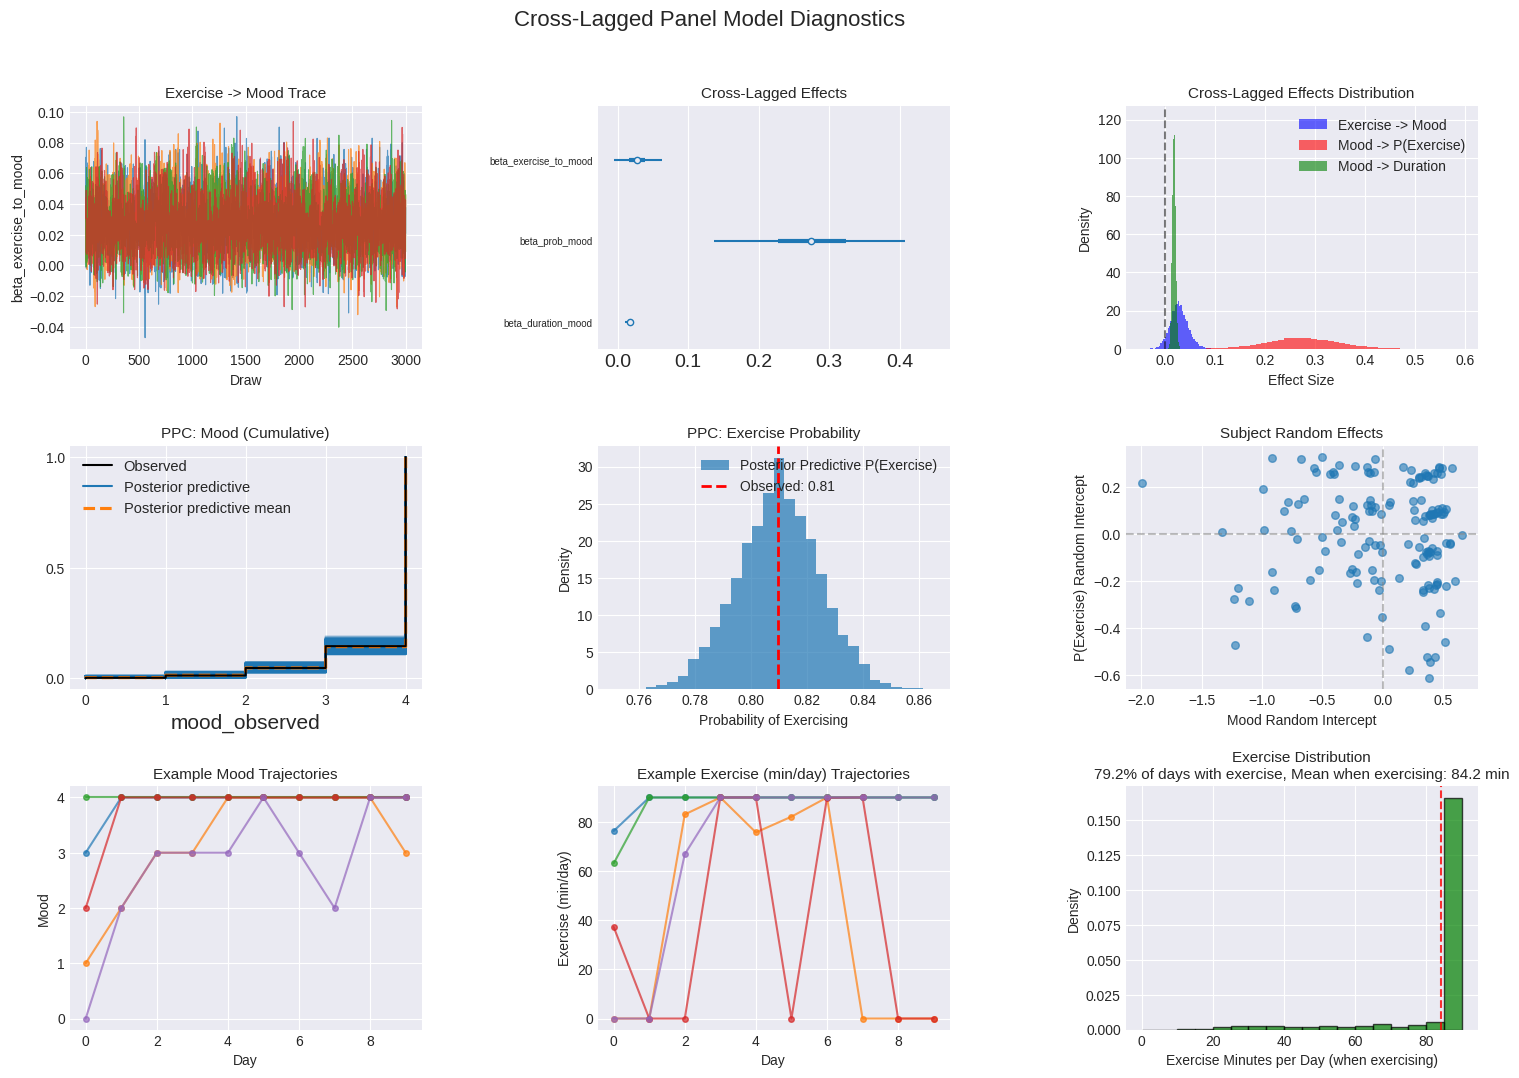

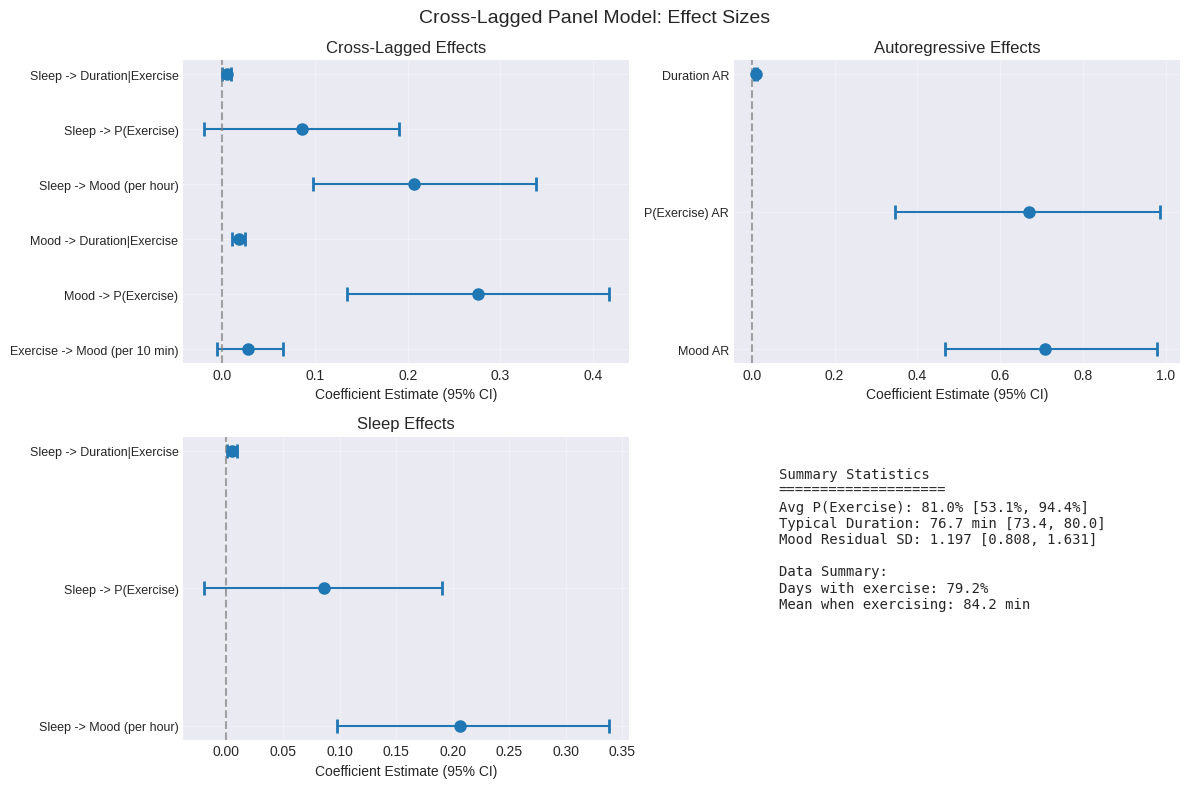


6. Generating results report...

Max R-hat: 1.010 (should be < 1.01)
Min ESS bulk: 580 (should be > 400)
[DEBUG] Found log-likelihood variables: ['duration_observed', 'exercised_observed', 'mood_observed']


/usr/local/lib/python3.11/dist-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.


CROSS-LAGGED PANEL MODEL RESULTS
Two-Part Model: P(Exercise) and Duration|Exercise
Daily Measurements (Mood, Exercise Minutes, Sleep Hours)

=== Data Summary ===
Number of subjects: 150
Number of days: 10
Proportion of days with exercise: 79.2%
Exercise when active: 84.2 min/day (SD: 15.0)
Exercise range when active: 13.3 - 90.0 minutes
Sleep mean: 7.5 hours/night (SD: 1.4)

=== Model Convergence ===
                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_mood_autoreg      0.707  0.130   0.460    0.951      0.005    0.002   
beta_exercise_to_mood  0.028  0.018  -0.005    0.062      0.000    0.000   
beta_prob_autoreg      0.671  0.164   0.371    0.985      0.004    0.001   
beta_prob_mood         0.276  0.072   0.137    0.407      0.001    0.001   
beta_duration_autoreg  0.009  0.002   0.006    0.012      0.000    0.000   
beta_duration_mood     0.017  0.003   0.011    0.024      0.000    0.000   
sigma_mood_residual    1.197  0.210   0.802    1.582      0.009

In [11]:
if __name__ == "__main__":
    # Run the workflow
    trace, data, report = run_crosslagged_analysis(
        n_subjects=150,
        n_days=10,
        seed=42,
        debug=True
    )

    # Save report to file
    # with open('crosslagged_results.txt', 'w') as f:
    #     f.write(report)